# Lesson 04 · Hypothesis testing and the false discovery rate

**Source:** *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 5 (pp. 36–44)

**Question:** We want a "Hall of Fame" of players whose true batting probability is above .300. How many can we admit while keeping wrong admissions under 5%?

**Goal:** Compute each player's posterior error probability (PEP), turn PEPs into q-values, and use them to control the false discovery rate.

**Contents**

1. Setup
2. Posterior error probabilities
3. False discovery rate of a chosen group
4. q-values
5. PEP vs q-value
6. Exercises: the frequentist route

**Tags:** `hypothesis-testing` `posterior-error-probability` `false-discovery-rate` `q-values` `multiple-testing`

**Before you start:** Lesson 03.

*How this notebook works:* each **Your turn** prompt is followed by an empty cell for your code. **Check** boxes give values to compare against; they come from the book, and your numbers can differ slightly because the Lahman data now runs through more recent seasons. **Reflect** prompts are for short written answers. Every prompt is numbered *lesson.section.question* (for example **2.3.1**), so you can refer to it; empty code cells and answer cells carry the same number.

In [1]:
# --- Setup: run this cell first ------------------------------------------
# Windows + conda: put the environment's DLL folders on PATH, so plotting
# can't crash the kernel when Jupyter wasn't started from the activated env.
import os, sys
for sub in ["Library\\mingw-w64\\bin", "Library\\usr\\bin", "Library\\bin", "Scripts", "bin"]:
    p = os.path.join(sys.prefix, sub)
    if os.path.isdir(p) and p not in os.environ["PATH"]:
        os.environ["PATH"] = p + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats, optimize, special

import eb_data   # helpers in this folder: loading the Lahman data, saving results

rng = np.random.default_rng(2017)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (7, 4)
print(f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}")

career = eb_data.career(pitcher_rule=None)
alpha0, beta0 = eb_data.load_prior()
print(f"{len(career):,} players | prior alpha0 = {alpha0:.1f}, beta0 = {beta0:.1f}")

numpy 2.5.3 | pandas 3.0.6 | scipy 1.18.1
11,725 players | prior alpha0 = 95.3, beta0 = 271.5


## 1. Setup

**4.1.1 · Your turn.** Add `eb_estimate`, `alpha1` and `beta1` to `career`, as in Lesson 03.

In [2]:
# 4.1.1 · Your code here
career['alpha1'] = alpha0 + career.H
career['beta1'] = beta0 + career.AB - career.H
career['eb_estimate'] = (career.alpha1 / (career.alpha1 + career.beta1))
career.head()


,playerID,name,H,AB,average,alpha1,beta1,eb_estimate
0,aaronha01,Hank Aaron,3771,12364,0.3050,3866.3306,8864.4864,0.3037
1,aaronto01,Tommie Aaron,216,944,0.2288,311.3306,999.4864,0.2375
2,abadan01,Andy Abad,2,21,0.0952,97.3306,290.4864,0.2510
3,abadijo01,John Abadie,11,49,0.2245,106.3306,309.4864,0.2557
4,abbated01,Ed Abbaticchio,772,3044,0.2536,867.3306,2543.4864,0.2543


## 2. Posterior error probabilities

For our Hall of Fame, the error is admitting a player whose true average is *below* .300. The **posterior error probability** is the posterior probability of exactly that:

$$\text{PEP}_i = \Pr(p_i < 0.3 \mid H_i, AB_i) = F_{\text{Beta}(\alpha_{1,i},\, \beta_{1,i})}(0.3).$$

**4.2.1 · Your turn.** Find Hank Aaron's posterior, plot it, and shade the area below .300. Compute his PEP with `stats.beta.cdf`.

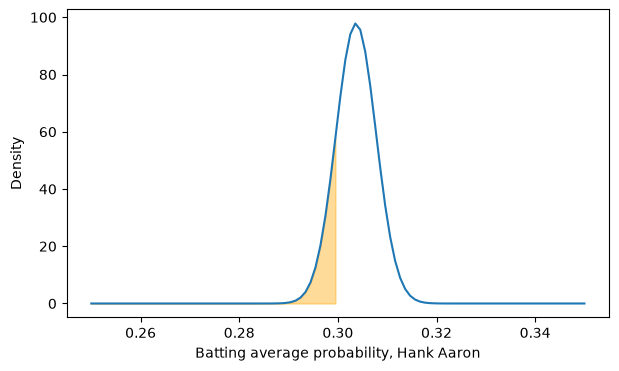

[0.18219217]


Seems to be right in the middle, 18.2% of our check range

In [3]:
# 4.2.1 · Your code here

hank = career[career['name'] == 'Hank Aaron']
x = np.linspace(0.25, 0.35, 100)
hank_post = stats.beta(hank.alpha1, hank.beta1)
plt.plot(x, hank_post.pdf(x))
plt.fill_between(x[x < 0.3], hank_post.pdf(x[x < 0.3]), color="orange", alpha=0.4)
plt.ylabel('Density')
plt.xlabel('Batting average probability, Hank Aaron')
plt.show()

pep = hank_post.cdf(0.3)
print(pep)
from IPython.display import display, Markdown
display(Markdown('Seems to be right in the middle, 18.2% of our check range'))

> **Check:** Hank Aaron's PEP ≈ 0.17–0.19, depending on your prior.

**4.2.2 · Your turn.** Compute `PEP` for every player. Plot a histogram of PEPs, and a scatter of `eb_estimate` against `PEP` colored by log AB.

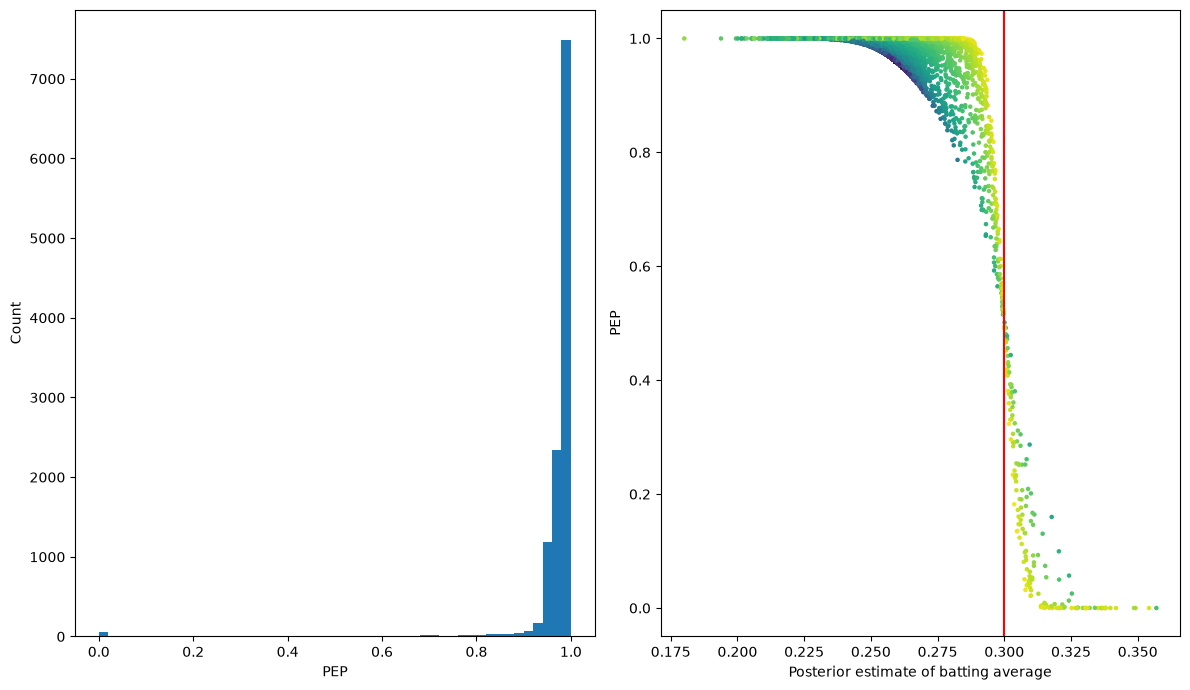

In [4]:
# 4.2.2 · Your code here
from matplotlib import colors
career['PEP'] = stats.beta(career.alpha1, career.beta1).cdf(0.3)
fig, axes = plt.subplots(1, 2, figsize=(12, 7))   # 2 rows, 3 columns

axes[0].hist(career.PEP, bins=50)
axes[0].set_xlabel('PEP')
axes[0].set_ylabel('Count')

axes[1].scatter(career.eb_estimate, career.PEP, c=career.AB, norm=colors.LogNorm(), cmap="viridis", s=5)
axes[1].set_xlabel('Posterior estimate of batting average')
axes[1].set_ylabel('PEP')
axes[1].axvline(0.3, 0, 1, color = 'red')
plt.tight_layout()   # stops titles and labels from overlapping
plt.show()


**4.2.3 · Reflect.** Why does the PEP cross 0.5 right where the shrunken estimate crosses .300? And why can two players with the same shrunken estimate have very different PEPs?

*4.2.3 · Your answer:*

Our PEP crosses 0.5 at an estimated mean batting average of 0.300 because that's what we decided as our cutoff for including a player in the Hall of Fame. Every player's PEP is determined by which fraction of their posterior batting average distribution is below 0.3. So it makes sense that our PEP plot cross 50% at our designated cutoff point- these are players whom we are most uncertain whether or not they belong in the hall of fame. Half their distribution is above our cutoff, half below, so it's really a coin flip whether they belong or not, given the data we have.

As for the second question, a player's PEP is the cumulative area less than our chosen batting average, so while two players may have two posterior distributions centered in the same location, the width of that distribution will vary with ABs, and so have differing proportions of their distribution behind 0.300.


## 3. False discovery rate of a chosen group

If we admit a group of players, the expected number of mistakes is the sum of their PEPs, so the expected *fraction* of mistakes is their mean PEP.

**4.3.1 · Your turn.** Sort by PEP. For the top 50, 100 and 200 players, compute the expected number of false discoveries and the mean PEP. Look at the players ranked 90–100.

In [5]:
# 4.3.1 · Your code here
career = career.sort_values(['PEP'], ascending = True)
career['Rank'] = range(1, len(career) + 1)
print((career.head(50).PEP.sum())/50, (career.head(100).PEP.sum())/100, (career.head(200).PEP.sum())/200)
career.iloc[90:100]

0.0008248714987394871 0.03656680052658399 0.19900977175302326


,playerID,name,H,AB,average,alpha1,beta1,eb_estimate,PEP,Rank
11197,whatlda01,David Whatley,318,948,0.3354,413.3306,901.4864,0.3144,0.1305,91
7245,mitchda01,Dale Mitchell,1244,3984,0.3122,1339.3306,3011.4864,0.3078,0.1312,92
6807,mccosba01,Barney McCosky,1301,4172,0.3118,1396.3306,3142.4864,0.3076,0.1321,93
7275,molitpa01,Paul Molitor,3319,10835,0.3063,3414.3306,7787.4864,0.3048,0.1347,94
1480,cabremi01,Miguel Cabrera,3174,10356,0.3065,3269.3306,7453.4864,0.3049,0.1353,95
7101,meuseir01,Irish Meusel,1521,4900,0.3104,1616.3306,3650.4864,0.3069,0.1390,96
4269,hallge01,George Hall,538,1671,0.3220,633.3306,1404.4864,0.3108,0.1462,97
10585,tobinja01,Jack Tobin,1906,6174,0.3087,2001.3306,4539.4864,0.3060,0.1471,98
6901,mcinnst01,Stuffy McInnis,2405,7822,0.3075,2500.3306,5688.4864,0.3053,0.1472,99
11176,wesleed01,Edgar Wesley,603,1886,0.3197,698.3306,1554.4864,0.3100,0.1528,100


> **Check:** top 100 → mean PEP ≈ 0.05; top 50 → ≈ 0.002; top 200 → ≈ 0.27.

## 4. q-values

Doing that for every cutoff at once gives the **q-value**: the cumulative mean of the sorted PEPs. Admitting everyone with `qvalue < 0.05` keeps the expected false discovery rate below 5%.

**4.4.1 · Your turn.** Add a `qvalue` column (sort by PEP, then `.expanding().mean()` or `np.cumsum(...) / np.arange(1, n + 1)`). How many players have q < 0.05? And q < 0.01?

In [6]:
# 4.4.1 · Your code here
career['qvalue'] = np.cumsum(career.PEP)/career.Rank
print(career.head())
print(len(career[career.qvalue < 0.05]), len(career[career.qvalue < 0.01]))

       playerID                  name     H    AB  average     alpha1  \
4883  hornsro01        Rogers Hornsby  2930  8173   0.3585  3025.3306   
2618  delahed01          Ed Delahanty  2597  7510   0.3458  2692.3306   
5526  keelewi01         Willie Keeler  2932  8591   0.3413  3027.3306   
5111  jacksjo01  Shoeless Joe Jackson  1772  4981   0.3558  1867.3306   
5877  lajoina01            Nap Lajoie  3243  9590   0.3382  3338.3306   

          beta1  eb_estimate         PEP  Rank      qvalue  
4883  5514.4864       0.3543  2.3707e-27     1  2.3707e-27  
2618  5184.4864       0.3418  6.4938e-16     2  3.2469e-16  
5526  5930.4864       0.3380  4.6446e-15     3  1.7647e-15  
5111  3480.4864       0.3492  5.2435e-15     4  2.6344e-15  
5877  6618.4864       0.3353  1.4854e-14     5  5.0783e-15  
111 71


> **Check:** the book got 97 players at 5% and 64 at 1%.

**4.4.2 · Your turn.** Plot the number of players admitted against the q-value threshold, for thresholds from 0 to 0.3.

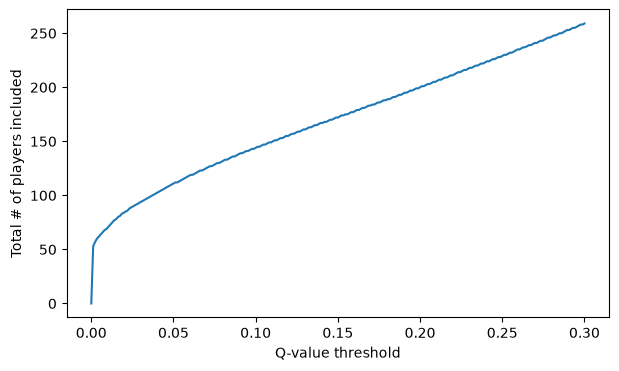

In [7]:
# 4.4.2 · Your code here
xs = np.linspace(0, 0.30, len(career[career.qvalue < 0.3]))
y = []
for x in xs:
    y.append(len(career[career.qvalue < x]))
plt.plot(xs, y, markersize=12, linestyle='-')
plt.xlabel('Q-value threshold')
plt.ylabel('Total # of players included')
plt.show()

## 5. PEP vs q-value

**4.5.1 · Reflect.** Hank Aaron's PEP is about 17%, yet he gets in under a 5% FDR. Explain how, in your own words. The book compares it to keeping a group's *average height* above a target.

*4.5.1 · Your answer:*

FDR is a cumulative or running average of multiple players' PEP. His individual (local) PEP is above our cutoff, but all the players ahead of him with lower PEP values help keep him, averaged, under our 5% cutoff.

## 6. Exercises: the frequentist route

**4.6.1 · Your turn.** For every player, compute a one-sided binomial p-value for H₀: p ≤ 0.300 (`stats.binom.sf(H - 1, AB, 0.3)`). Apply Benjamini–Hochberg with `stats.false_discovery_control` and admit those with adjusted p < 0.05. How does this list compare with the q-value list? Which players differ, and why?

In [8]:
# 4.6.1 · Your code here

**4.6.2 · Your turn.** **Card connection.** Use your simulated Pokémon card sets from 2.8.2 or 3.5.2. Each has a *pull rate*: the chance that one booster pack contains a rare card, a *hit*. Collectors often quote a rule of thumb like "one hit every 20 packs". Flag the sets whose pull rate is above 1 in 20 while keeping the FDR at 10%.

In [9]:
# 4.6.2 · Setup: load the card sets (with alpha1, beta1) saved after 3.5.2, and the card prior
sets = eb_data.load_saved_table("card_sets_posterior")
p = eb_data.load_result("card_prior")
alpha_pull, beta_pull = p["alpha0"], p["beta0"]
print(f"Card prior: Beta({alpha_pull:.2f}, {beta_pull:.2f})")
sets.head()

FileNotFoundError: results/card_sets_posterior.csv not found. Run the save cell after 3.5.2 (Lesson 03) first.

In [ ]:
# 4.6.2 · Your code here



In [ ]:
# 4.6.2 · Save the sets with your FDR results for later lessons
eb_data.save_table("card_sets_fdr", sets)

## References

- *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 5.
- Storey (2002), "A direct approach to false discovery rates", *JRSS B* 64(3).
- Käll, Storey, MacCoss & Noble (2008), "Posterior error probabilities and false discovery rates: two sides of the same coin", *J. Proteome Research* 7(1).
- SciPy `false_discovery_control`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.false_discovery_control.html